In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import functools
conn = duckdb.connect()
@functools.lru_cache(maxsize=1024)
def q(query: str):
    return conn.execute(query).df()

import matplotlib.pylab as pylab
params = {
    'legend.fontsize': 'large',
    'figure.figsize': (6, 4),
    'axes.labelsize': 'large',
    'axes.titlesize':'large',
    'xtick.labelsize':'large',
    'ytick.labelsize':'large',
    # 'title.fontsize': 'x-large',
}
pylab.rcParams.update(params)

In [29]:
%cd analysis

[Errno 2] No such file or directory: 'analysis'
/home/isaackhor/code/cfcache/analysis


In [30]:
# source rename for review anonymisation
rename_tbl = {
    'cf_a': 'BOS 1',
    'cf_b': 'BOS 2',
    'cf_c': 'DXB 1',
    'cf_d': 'DXB 2',
    'cf_e': 'SIN 1',
    'cf_f': 'SIN 2',
    'cf_g': 'FRA 1',
    'cf_h': 'FRA 2',
    'fb_a': 'Meta 1',
    'fb_b': 'Meta 2',
    'fb_c': 'Meta 3',
    'wm_t': 'WM 1',
    'wm_u': 'WM 2',

    '106m105': 'BOS 1',
    '106m106': 'BOS 2',
    '243m12': 'DXB 1',
    '243m13': 'DXB 2',
    '411m264': 'SIN 1',
    '411m325': 'SIN 2',
    '472m378': 'FRA 1',
    '472m379': 'FRA 2',

    'fb_reag' : 'Meta 1',
    'fb_rhna' : 'Meta 2',
    'fb_rprn' : 'Meta 3',
}

import pickle
with open('rename_tbl.pkl', 'wb') as f:
    pickle.dump(rename_tbl, f)

def get_linestyle(source):
    if source.startswith('cf'):
        return 'solid'
    elif source.startswith('fb'):
        return 'dashed'
    elif source.startswith('wm'):
        return 'dotted'
    else:
        return 'solid'

# fig 1: distribtion of miss types in baseline

In [34]:
files = [
    '../results/r10i1_baseline_keep.csv',
]
df = pd.concat([pd.read_csv(f) for f in files])

df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['miss_mandatory_pct'] = df.miss_mandatory / df.miss_all
df['miss_expired_pct'] = df.miss_expired / df.miss_all
df['miss_evicted_pct'] = df.miss_evicted / df.miss_all
df['in_lbl'] = df['in'].map(rename_tbl).fillna(df['in'])

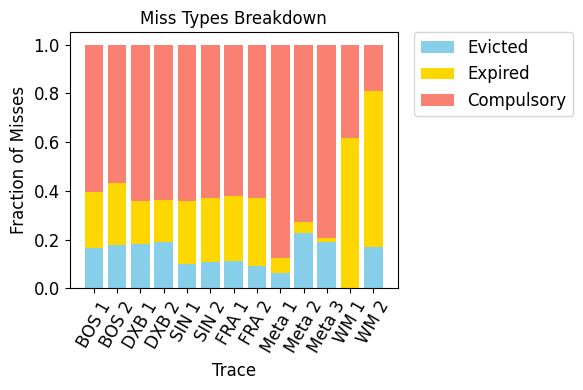

In [35]:
# get stacked bar plot of miss types
miss_types = df[df.cache_type == 'lru']
miss_types = miss_types.sort_values(by='in')
plt.figure(figsize=(6, 4))
plt.bar(miss_types['in_lbl'], miss_types['miss_evicted_pct'], label='Evicted', color='skyblue')
plt.bar(miss_types['in_lbl'], miss_types['miss_expired_pct'], bottom=miss_types['miss_evicted_pct'], label='Expired', color='gold')
plt.bar(miss_types['in_lbl'], miss_types['miss_mandatory_pct'], bottom=miss_types['miss_evicted_pct'] + miss_types['miss_expired_pct'], label='Compulsory', color='salmon')
plt.xlabel('Trace')
plt.ylabel('Fraction of Misses')
plt.title('Miss Types Breakdown')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig('../paper/figs/miss_types_by_trace.png')

# results - oracle / ml tradeoff curves

In [36]:
r9files = [
    '../results/r9i2_baseline.csv',
    '../results/r9i2_oracle.csv',
    '../results/r9i4_ml_cf_rfc.csv',
    '../results/r9i4_ml_fb_rfc.csv',
    '../results/r9i4_ml_wm_rfc.csv',
]
r10files = [
    '../results/r10i1_baseline.csv',
    '../results/r10i1_oracle.csv',
    '../results/r10i1_ml_cf_rfc.csv',
    '../results/r10i1_ml_fb_rfc.csv',
    '../results/r10i1_ml_wm_rfc.csv',
    '../results/r10i1_ml_wm_rfc_extended.csv',
    '../results/r10i1_ml_fb_rfc_extended2.csv',
    '../results/r10i1_ml_wm_rfc_extended2.csv',
]
df = pd.concat([pd.read_csv(f) for f in r10files])

df = df.drop(columns=['rv_min_ttl', 'rv_min_freq', 'rv_max_za'])
df = df.drop_duplicates().sort_values(by=['mode', 'in', 'cache_type', 'mlthres'])
df['trace'] = df['in'].map(rename_tbl).fillna(df['in'])
df['hit_all'] = df['hit_fresh'] + df['hit_reval'] + df['hit_stale']
df['hit_pc'] = df['hit_all'] / df['all'] * 100
df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['rv_pending'] = df.revals - df.hit_reval - df.reval_wasted
df['optmiss'] = (df['miss_all'] - df['miss_mandatory']) / df['all'] * 100
df['amp_lower'] = df['reval_wasted'] / (df['miss_all'] + df['hit_reval']) + 1
df['amp_upper'] = (df['reval_wasted'] + df['rv_pending']) / (df['miss_all'] + df['hit_reval']) + 1
df['amp_avg'] = (df['amp_lower'] + df['amp_upper']) / 2
df

,in,gib,ksr,cache_type,mode,model,mlthres,evict_expired,all,hit_fresh,...,reval_wasted,trace,hit_all,hit_pc,miss_all,rv_pending,optmiss,amp_lower,amp_upper,amp_avg
35,cf_a,2048,1,arc,ml,models/v10_cf_rfc.onnx,0.66,True,348839958,310805476,...,3763247,BOS 1,314339173,90.109853,34500785,2131,3.633934,1.098943,1.098999,1.098971
36,cf_a,2048,1,arc,ml,models/v10_cf_rfc.onnx,0.68,True,348839958,310826648,...,1347575,BOS 1,314093536,90.039438,34746422,-3812,3.704349,1.035450,1.035350,1.035400
34,cf_a,2048,1,arc,ml,models/v10_cf_rfc.onnx,0.70,True,348839958,310845019,...,1045562,BOS 1,313823672,89.962077,35016286,-4781,3.781710,1.027518,1.027393,1.027456
32,cf_a,2048,1,arc,ml,models/v10_cf_rfc.onnx,0.75,True,348839958,310882102,...,570355,BOS 1,313304332,89.813201,35535626,-8157,3.930586,1.015026,1.014811,1.014919
30,cf_a,2048,1,arc,ml,models/v10_cf_rfc.onnx,0.80,True,348839958,310878293,...,346709,BOS 1,312901325,89.697673,35938633,-10175,4.046114,1.009133,1.008865,1.008999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,wm_u,2048,8,lru,oracle,NaN,4.00,True,177900394,160093046,...,5298800,WM 2,174019391,97.818440,3881003,181346,0.481989,1.297563,1.307746,1.302654
244,wm_u,2048,8,sieve,oracle,NaN,1.00,True,177900394,160592937,...,0,WM 2,171065120,96.157808,6835274,-87003,2.142621,1.000000,0.994973,0.997487
245,wm_u,2048,8,sieve,oracle,NaN,2.00,True,177900394,160274676,...,1838516,WM 2,172761464,97.111344,5138930,-55809,1.189085,1.104309,1.101142,1.102726
246,wm_u,2048,8,sieve,oracle,NaN,3.00,True,177900394,160152169,...,3654174,WM 2,173561370,97.560981,4339024,57038,0.739448,1.205890,1.209103,1.207496


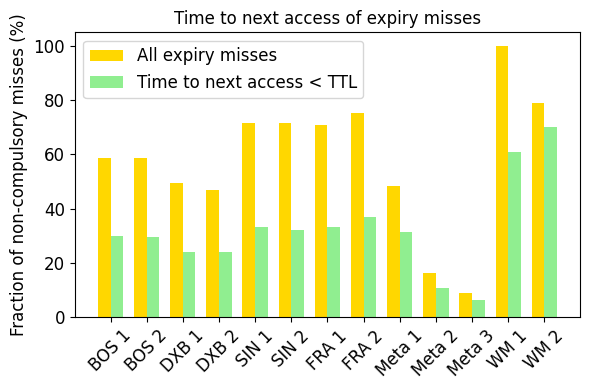

In [56]:
oracledf = df[(df['cache_type'] == 'lru') & ((df['mode'] == 'oracle') | (df['mode'] == 'never'))]

plt.figure(figsize=(6, 4))
ndf = oracledf[oracledf['mode'] == 'never'].sort_values(by='in').reset_index()
odf1 = oracledf[(oracledf['mode'] == 'oracle') & (oracledf['mlthres'] == 1)].sort_values(by='in').reset_index()
odf2 = oracledf[(oracledf['mode'] == 'oracle') & (oracledf['mlthres'] == 2)].sort_values(by='in').reset_index()
odf3 = oracledf[(oracledf['mode'] == 'oracle') & (oracledf['mlthres'] == 3)].sort_values(by='in').reset_index()

expmax = miss_types['miss_expired'] / (miss_types['miss_expired'] + miss_types['miss_evicted'])
oracle1 = 100 - (odf1['optmiss'] / ndf['optmiss'] * 100)
oracle2 = 100 - (odf2['optmiss'] / ndf['optmiss'] * 100)
oracle3 = 100 - (odf3['optmiss'] / ndf['optmiss'] * 100)
x = np.arange(len(odf1['trace'])) 
width = 0.35  # Width of each bar

# 2. Plot bars with offsets
# Subtract half the width for the first group, add for the second
plt.bar(x - width/2, expmax * 100, width, color='gold', label='All expiry misses')
plt.bar(x + width/2, oracle1, width, color='lightgreen', label='Time to next access < TTL')

# 3. Fix the labels
plt.xticks(x, odf1['trace'], rotation=45)
plt.title('Time to next access of expiry misses')
plt.ylabel('Fraction of non-compulsory misses (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../paper/figs/oracle_eligible.png')
plt.show()

Text(0, 0.5, 'Optional Miss Rate (% of baseline)')

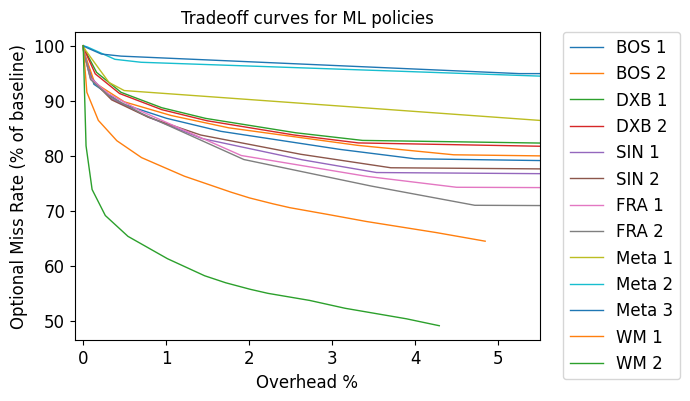

In [8]:
mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')][['in', 'trace', 'mlthres', 'optmiss', 'amp_avg']]
for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    plt.plot((subset['amp_avg'] - 1) * 100, subset['optmiss'] / nevermax * 100, marker='', ms=4, linewidth=1, label=trace)
plt.xlim(-0.1, 5.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Tradeoff curves for ML policies')
plt.xlabel('Overhead %')
plt.ylabel('Optional Miss Rate (% of baseline)')
# plt.savefig('../paper/figs/ml_tradeoff_norm.png')

Text(0, 0.5, 'Optional Miss Rate (% of baseline)')

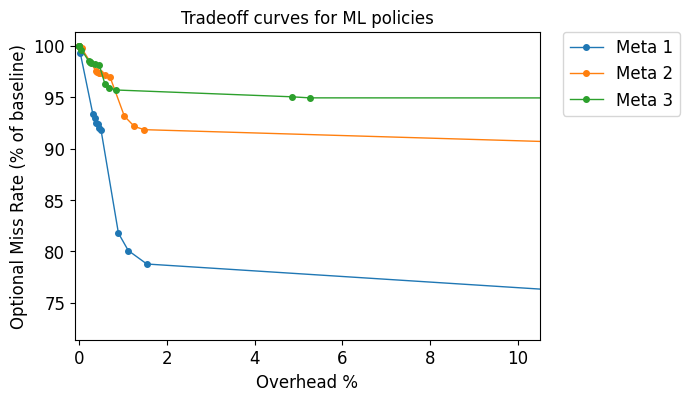

In [8]:
mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')][['in', 'trace', 'mlthres', 'optmiss', 'amp_avg']]
for i in ['fb_a', 'fb_b', 'fb_c']:
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    plt.plot((subset['amp_avg'] - 1) * 100, subset['optmiss'] / nevermax * 100, marker='o', ms=4, linewidth=1, label=trace)
plt.xlim(-0.1, 10.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Tradeoff curves for ML policies')
plt.xlabel('Overhead %')
plt.ylabel('Optional Miss Rate (% of baseline)')
# plt.savefig('../paper/figs/ml_tradeoff_norm.png')

Text(0, 0.5, 'Optional Miss Rate (% of baseline)')

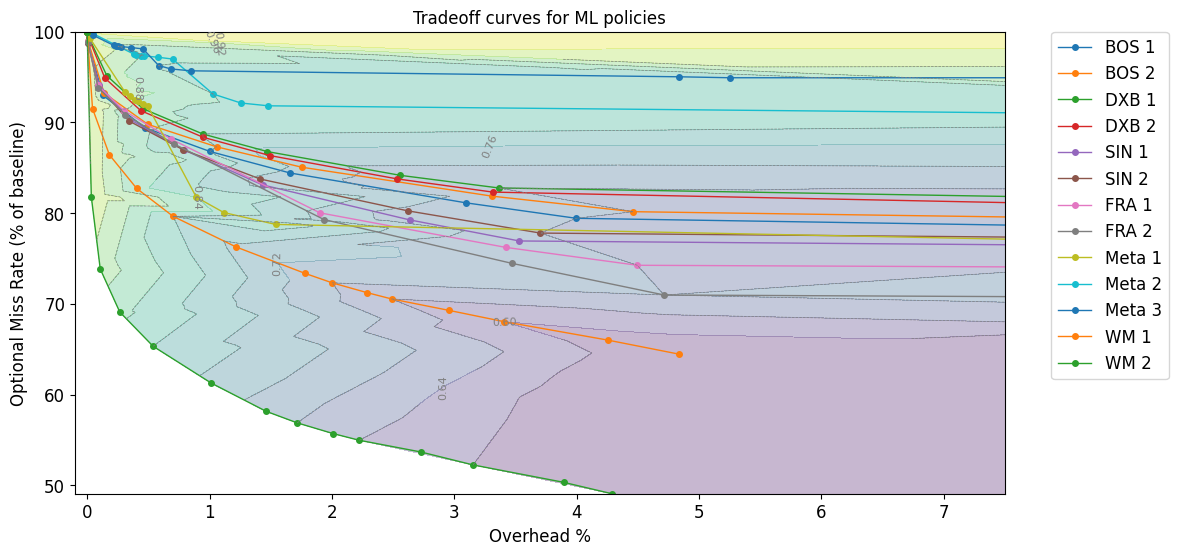

In [21]:
mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')][['in', 'trace', 'mlthres', 'optmiss', 'amp_avg']]

all_x = []
all_y = []
all_z = []

plt.figure(figsize=(12,6))

for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')

    x = (subset['amp_avg'] - 1) * 100
    y = subset['optmiss'] / nevermax * 100
    z = subset['mlthres']

    all_x.extend(x.values)
    all_y.extend(y.values)
    all_z.extend(z.values)

    plt.plot((subset['amp_avg'] - 1) * 100, subset['optmiss'] / nevermax * 100, marker='o', ms=4, linewidth=1, label=trace)

# Create contour lines
try:
    # Use tricontour to interpolate and draw contour lines across the unstructured grid of points
    # We select levels corresponding to specific mlthres values if possible, or let it auto-select
    cntr = plt.tricontour(all_x, all_y, all_z, levels=10, linewidths=0.5, colors='gray', linestyles='dashed')
    plt.tricontourf(all_x, all_y, all_z, levels=10, cmap='viridis', alpha=0.3)  # Optional: filled contours for better visualization
    plt.clabel(cntr, inline=True, fontsize=8, fmt='%.2f')
except Exception as e:
    print(f"Could not plot contours: {e}")

plt.xlim(-0.1, 7.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Tradeoff curves for ML policies')
plt.xlabel('Overhead %')
plt.ylabel('Optional Miss Rate (% of baseline)')

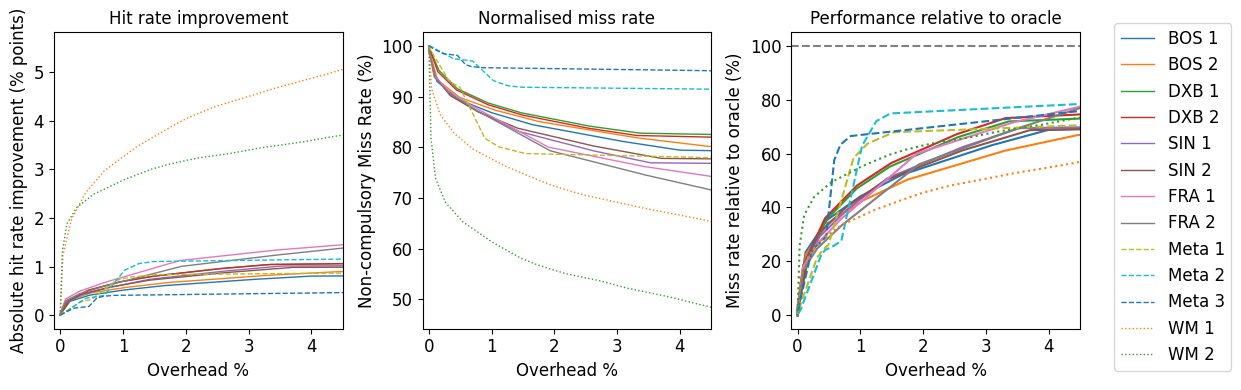

In [61]:
mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')][['in', 'trace', 'mlthres', 'optmiss', 'amp_avg', 'mode']]

fig, axs = plt.subplots(1, 3, figsize=(11, 4))

for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    axs[0].plot((subset['amp_avg'] - 1) * 100, nevermax - subset['optmiss'], marker='', ms=4, linewidth=1, label=trace, linestyle=get_linestyle(i))

axs[0].set_xlim(-0.1, 4.5)
axs[0].set_title('Hit rate improvement')
axs[0].set_xlabel('Overhead %')
axs[0].set_ylabel('Absolute hit rate improvement (% points)')

for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    axs[1].plot((subset['amp_avg'] - 1) * 100, subset['optmiss'] / nevermax * 100, marker='', ms=4, linewidth=1, label=trace, linestyle=get_linestyle(i))

axs[1].set_xlim(-0.1, 4.5)
axs[1].set_title('Normalised miss rate')
axs[1].set_xlabel('Overhead %')
axs[1].set_ylabel('Non-compulsory Miss Rate (%)')

dflru = df[df['cache_type'] == 'lru']
for i in sorted(dflru['in'].unique()):
    df_s = dflru[(dflru['in'] == i) & (dflru['mode'] == 'ml')].sort_values('mlthres')
    never_y = dflru[(dflru['in'] == i) & (dflru['mode'] == 'never')]['optmiss']
    oracle_y = dflru[(dflru['in'] == i) & (dflru['mode'] == 'oracle')]['optmiss']
    never_frac = never_y.values[0]
    oracle_frac = oracle_y.max()
    optimal = oracle_frac - never_frac
    axs[2].plot((df_s['amp_avg'] - 1) * 100, (df_s['optmiss'] - never_frac)/ optimal * 100, marker='', label=rename_tbl.get(i, i), linestyle=get_linestyle(i))

axs[2].axhline(y=100, color='gray', linestyle='--')
axs[2].set_xlabel('Overhead %')
axs[2].set_ylabel('Miss rate relative to oracle (%)')
axs[2].set_xlim(-0.1, 4.5)
axs[2].set_title('Performance relative to oracle')

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.95), loc='upper left')
plt.tight_layout()
plt.savefig('../paper/figs/ml_tradeoff_combined.png', bbox_inches='tight')

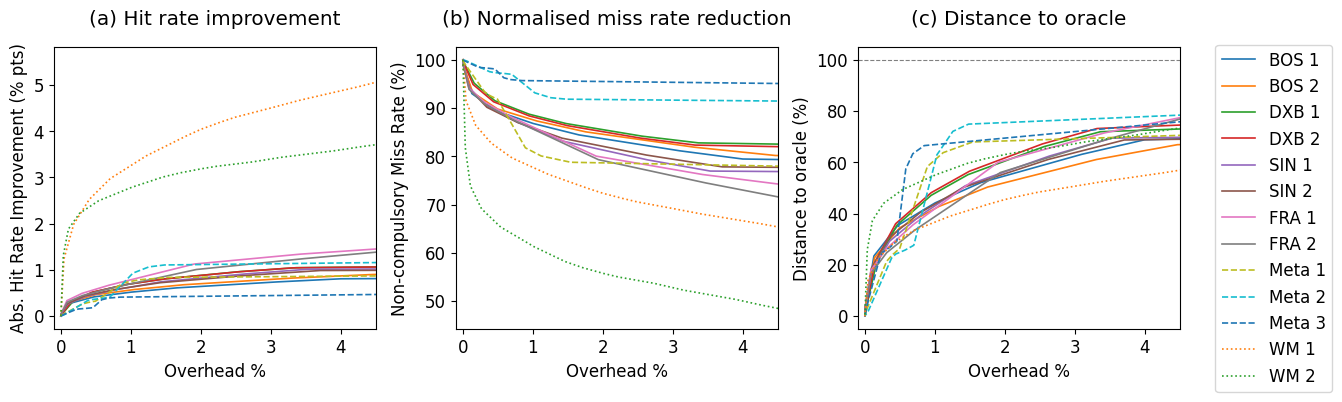

In [ ]:
# # Basic styling for clarity and readability
# plt.rcParams.update({
#     "axes.labelsize": 10,
#     "font.size": 10,
#     "legend.fontsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9
# })

# 1. Filter and Prepare Data
mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')][['in', 'trace', 'mlthres', 'optmiss', 'amp_avg', 'mode']]

# 2. Initialize Figure
# Slightly taller height (4.5) to ensure bottom titles aren't cramped
fig, axs = plt.subplots(1, 3, figsize=(12, 4.5))

# --- Plot 0: Hit rate improvement ---
for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    axs[0].plot((subset['amp_avg'] - 1) * 100, nevermax - subset['optmiss'], 
                marker='', ms=4, linewidth=1.2, label=trace, linestyle=get_linestyle(i))

axs[0].set_xlim(-0.1, 4.5)
axs[0].set_ylabel('Abs. Hit Rate Improvement (% pts)')
axs[0].set_xlabel('Overhead %')
# y < 0 moves the title below the axis
axs[0].set_title('(a) Hit rate improvement', y=1.05, fontsize='x-large')

# --- Plot 1: Normalised miss rate reduction ---
for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    axs[1].plot((subset['amp_avg'] - 1) * 100, subset['optmiss'] / nevermax * 100, 
                marker='', ms=4, linewidth=1.2, label=trace, linestyle=get_linestyle(i))

axs[1].set_xlim(-0.1, 4.5)
axs[1].set_ylabel('Non-compulsory Miss Rate (%)')
axs[1].set_xlabel('Overhead %')
axs[1].set_title('(b) Normalised miss rate reduction', y=1.05, fontsize='x-large')

# --- Plot 2: Distance to Oracle ---
dflru = df[df['cache_type'] == 'lru']
for i in sorted(dflru['in'].unique()):
    df_s = dflru[(dflru['in'] == i) & (dflru['mode'] == 'ml')].sort_values('mlthres')
    never_y = dflru[(dflru['in'] == i) & (dflru['mode'] == 'never')]['optmiss']
    oracle_y = dflru[(dflru['in'] == i) & (dflru['mode'] == 'oracle')]['optmiss']
    never_frac = never_y.values[0]
    oracle_frac = oracle_y.max()
    optimal = oracle_frac - never_frac
    axs[2].plot((df_s['amp_avg'] - 1) * 100, (df_s['optmiss'] - never_frac)/ optimal * 100, 
                marker='', linewidth=1.2, label=rename_tbl.get(i, i), linestyle=get_linestyle(i))

axs[2].axhline(y=100, color='gray', linestyle='--', linewidth=0.8)
axs[2].set_xlim(-0.1, 4.5)
axs[2].set_ylabel('Distance to oracle (%)')
axs[2].set_xlabel('Overhead %')
axs[2].set_title('(c) Distance to oracle', y=1.05, fontsize='x-large')

# 3. Legend and Final Layout
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.9), loc='upper left', frameon=True)

# Use tight_layout first to handle basic spacing
plt.tight_layout()
# Manually adjust the bottom margin to make room for the titles
plt.subplots_adjust(bottom=0.25)

plt.savefig('../paper/figs/ml_tradeoff_combined.png', bbox_inches='tight', dpi=300)
plt.show()

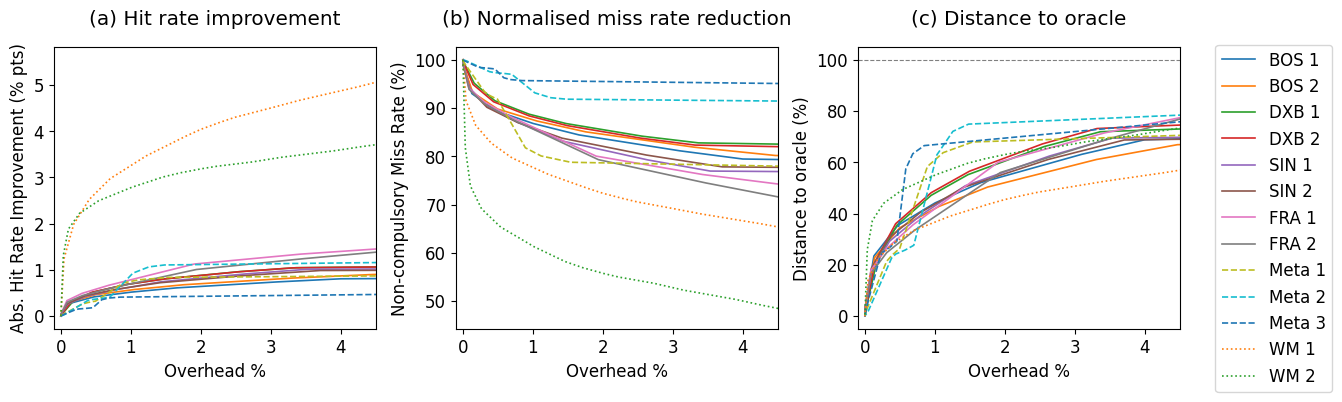

In [ ]:
# 1. Filter and Prepare Data
mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')][['in', 'trace', 'mlthres', 'optmiss', 'amp_avg', 'mode']]

# 2. Initialize Figure
# Slightly taller height (4.5) to ensure bottom titles aren't cramped
fig, axs = plt.subplots(1, 3, figsize=(12, 4.5))

# --- Plot 0: Hit rate improvement ---
for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    axs[0].plot((subset['amp_avg'] - 1) * 100, nevermax - subset['optmiss'], 
                marker='', ms=4, linewidth=1.2, label=trace, linestyle=get_linestyle(i))

axs[0].set_xlim(-0.1, 4.5)
axs[0].set_ylabel('Abs. Hit Rate Improvement (% pts)')
axs[0].set_xlabel('Overhead %')
# y < 0 moves the title below the axis
axs[0].set_title('(a) Hit rate improvement', y=1.05, fontsize='x-large')

# --- Plot 1: Normalised miss rate reduction ---
for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    axs[1].plot((subset['amp_avg'] - 1) * 100, subset['optmiss'] / nevermax * 100, 
                marker='', ms=4, linewidth=1.2, label=trace, linestyle=get_linestyle(i))

axs[1].set_xlim(-0.1, 4.5)
axs[1].set_ylabel('Non-compulsory Miss Rate (%)')
axs[1].set_xlabel('Overhead %')
axs[1].set_title('(b) Normalised miss rate reduction', y=1.05, fontsize='x-large')

# --- Plot 2: Distance to Oracle ---
dflru = df[df['cache_type'] == 'lru']
for i in sorted(dflru['in'].unique()):
    df_s = dflru[(dflru['in'] == i) & (dflru['mode'] == 'ml')].sort_values('mlthres')
    never_y = dflru[(dflru['in'] == i) & (dflru['mode'] == 'never')]['optmiss']
    oracle_y = dflru[(dflru['in'] == i) & (dflru['mode'] == 'oracle')]['optmiss']
    never_frac = never_y.values[0]
    oracle_frac = oracle_y.max()
    optimal = oracle_frac - never_frac
    axs[2].plot((df_s['amp_avg'] - 1) * 100, (df_s['optmiss'] - never_frac)/ optimal * 100, 
                marker='', linewidth=1.2, label=rename_tbl.get(i, i), linestyle=get_linestyle(i))

axs[2].axhline(y=100, color='gray', linestyle='--', linewidth=0.8)
axs[2].set_xlim(-0.1, 4.5)
axs[2].set_ylabel('Distance to oracle (%)')
axs[2].set_xlabel('Overhead %')
axs[2].set_title('(c) Distance to oracle', y=1.05, fontsize='x-large')

# 3. Legend and Final Layout
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.9), loc='upper left', frameon=True)

# Use tight_layout first to handle basic spacing
plt.tight_layout()
# Manually adjust the bottom margin to make room for the titles
plt.subplots_adjust(bottom=0.25)

plt.savefig('../paper/figs/ml_tradeoff_combined.png', bbox_inches='tight', dpi=300)
plt.show()

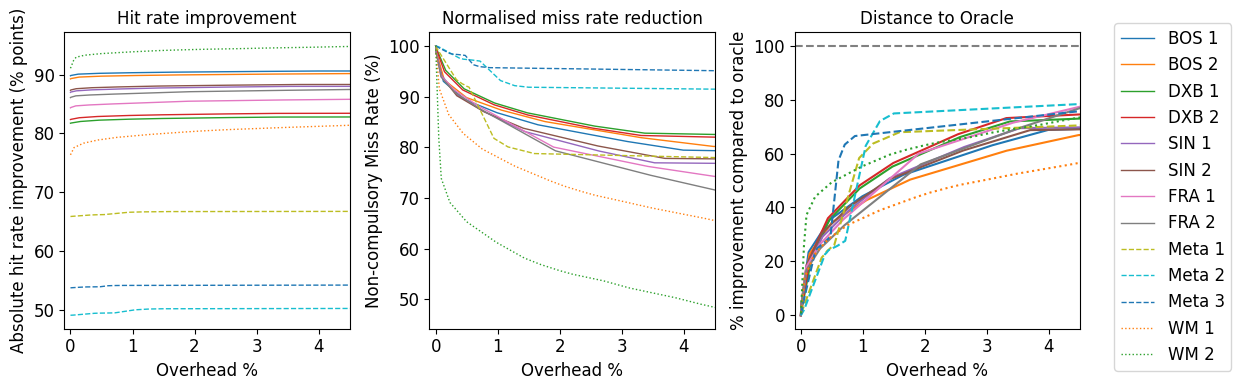

In [26]:
mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')][['in', 'trace', 'mlthres', 'optmiss', 'amp_upper', 'mode', 'hit_pc']]

fig, axs = plt.subplots(1, 3, figsize=(11, 4))

for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_upper')
    axs[0].plot((subset['amp_upper'] - 1) * 100, subset['hit_pc'], marker='', ms=4, linewidth=1, label=trace, linestyle=get_linestyle(i))

axs[0].set_xlim(-0.1, 4.5)
axs[0].set_title('Hit rate improvement')
axs[0].set_xlabel('Overhead %')
axs[0].set_ylabel('Absolute hit rate improvement (% points)')

for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_upper')
    axs[1].plot((subset['amp_upper'] - 1) * 100, subset['optmiss'] / nevermax * 100, marker='', ms=4, linewidth=1, label=trace, linestyle=get_linestyle(i))

axs[1].set_xlim(-0.1, 4.5)
axs[1].set_title('Normalised miss rate reduction')
axs[1].set_xlabel('Overhead %')
axs[1].set_ylabel('Non-compulsory Miss Rate (%)')

dflru = df[df['cache_type'] == 'lru']
for i in sorted(dflru['in'].unique()):
    df_s = dflru[(dflru['in'] == i) & (dflru['mode'] == 'ml')].sort_values('mlthres')
    never_y = dflru[(dflru['in'] == i) & (dflru['mode'] == 'never')]['optmiss']
    oracle_y = dflru[(dflru['in'] == i) & (dflru['mode'] == 'oracle')]['optmiss']
    never_frac = never_y.values[0]
    oracle_frac = oracle_y.max()
    optimal = oracle_frac - never_frac
    axs[2].plot((df_s['amp_upper'] - 1) * 100, (df_s['optmiss'] - never_frac)/ optimal * 100, marker='', label=rename_tbl.get(i, i), linestyle=get_linestyle(i))

axs[2].axhline(y=100, color='gray', linestyle='--')
axs[2].set_xlabel('Overhead %')
axs[2].set_ylabel('% improvement compared to oracle')
axs[2].set_xlim(-0.1, 4.5)
axs[2].set_title('Distance to Oracle')

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.95), loc='upper left')
plt.tight_layout()
plt.savefig('../paper/figs/ml_tradeoff_combined.png', bbox_inches='tight')

In [ ]:

mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')][['in', 'trace', 'mlthres', 'optmiss', 'amp_avg']]
for i in sorted(mldf['in'].unique()):
    trace = rename_tbl.get(i, i)
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    plt.plot((subset['amp_avg'] - 1) * 100, nevermax - subset['optmiss'], marker='o', ms=4, linewidth=1, label=trace)
plt.legend()
plt.xlim(-0.1, 5.5)
plt.title('Tradeoff curves for ML policies')
plt.xlabel('Overhead %')
plt.ylabel('Absolute hit rate improvement (% points)')
# plt.savefig('../paper/figs/ml_tradeoff_abs.png')

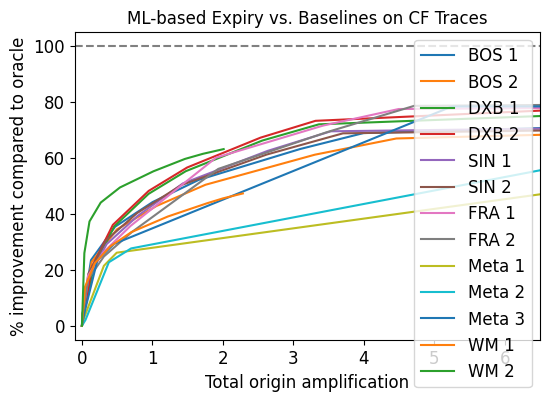

In [27]:
# normalised graph
dflru = df[df['cache_type'] == 'lru']
for i in sorted(dflru['in'].unique()):
    df_s = dflru[(dflru['in'] == i) & (dflru['mode'] == 'ml')].sort_values('mlthres')
    never_y = dflru[(dflru['in'] == i) & (dflru['mode'] == 'never')]['optmiss']
    oracle_y = dflru[(dflru['in'] == i) & (dflru['mode'] == 'oracle')]['optmiss']
    never_frac = never_y.values[0]
    oracle_frac = oracle_y.max()
    optimal = oracle_frac - never_frac
    plt.plot((df_s['amp_avg'] - 1) * 100, (df_s['optmiss'] - never_frac)/ optimal * 100, marker='', label=rename_tbl.get(i, i))

plt.axhline(y=100, color='gray', linestyle='--')
plt.xlabel('Total origin amplification')
plt.ylabel('% improvement compared to oracle')
plt.xlim(-0.1, 6.5)
plt.title('ML-based Expiry vs. Baselines on CF Traces')
plt.legend()
plt.show()


In [ ]:
for trace in ['cf_a', 'cf_b', 'cf_c', 'cf_d', 'cf_e', 'cf_f', 'cf_g', 'cf_h', 'fb_a', 'fb_b', 'fb_c']:
    mldf = df[(df['in'] == trace) & ((df['mode'] == 'ml') | (df['mode'] == 'never'))][['in', 'mlthres', 'optmiss', 'amp_avg', 'cache_type']]
    for ct in df['cache_type'].unique():
        nevermax = df[(df['mode'] == 'never') & (df['cache_type'] == ct) & (df['in'] == trace)]['optmiss'].values[0]
        oraclemin = df[(df['mode'] == 'oracle') & (df['cache_type'] == ct) & (df['in'] == trace) & (df['mlthres'] == 1)]['optmiss'].values[0]
        subset = mldf[mldf['cache_type'] == ct].sort_values(by='amp_avg')
        pc_oracle = (nevermax - subset['optmiss']) / (nevermax - oraclemin) * 100
        plt.plot((subset['amp_avg'] - 1) * 100, pc_oracle, marker='o', ms=4, linewidth=1, label=ct)
    plt.legend()
    plt.title(f'Tradeoff curves for ML policies, relative to oracle-1, trace={trace}')
    plt.xlim(-0.1, 5.5)
    plt.xlabel('Overhead %')
    plt.ylabel('Relative hit rate improvement (% of oracle)')
    plt.show()

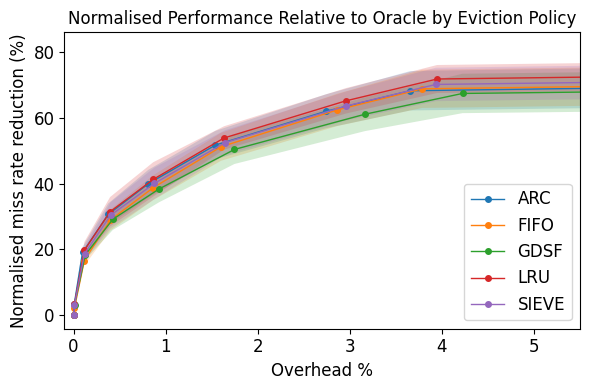

In [64]:
traces = ['cf_a', 'cf_b', 'cf_c', 'cf_d', 'cf_e', 'cf_f', 'cf_g', 'cf_h']
rows = []
for trace in traces:
    mldf = df[(df['in'] == trace) & ((df['mode'] == 'ml') | (df['mode'] == 'never'))][['in', 'mlthres', 'optmiss', 'amp_avg', 'cache_type']]
    for ct in df['cache_type'].unique():
        nevermax = df[(df['mode'] == 'never') & (df['cache_type'] == ct) & (df['in'] == trace)]['optmiss'].values[0]
        oraclemin = df[(df['mode'] == 'oracle') & (df['cache_type'] == ct) & (df['in'] == trace) & (df['mlthres'] == 1)]['optmiss'].values[0]
        subset = mldf[mldf['cache_type'] == ct].sort_values(by='amp_avg')
        pc_oracle = (nevermax - subset['optmiss']) / (nevermax - oraclemin) * 100
        rows.append(pd.DataFrame({
            'cache_type': ct,
            'mlthres': subset['mlthres'].values,
            'amp_avg': subset['amp_avg'].values,
            'pc_oracle': pc_oracle.values
        }))

alldf = pd.concat(rows, ignore_index=True)
agg = alldf.groupby(['cache_type', 'mlthres']).agg(
    pc_oracle_mean=('pc_oracle', 'mean'),
    pc_oracle_std=('pc_oracle', 'std'),
    amp_avg_mean=('amp_avg', 'mean')
).reset_index()

plt.figure(figsize=(6, 4))
for ct in sorted(agg['cache_type'].unique()):
    sub = agg[agg['cache_type'] == ct].sort_values('mlthres')
    x = (sub['amp_avg_mean'] - 1) * 100
    y = sub['pc_oracle_mean']
    yerr = sub['pc_oracle_std'].fillna(0)
    plt.plot(x, y, marker='o', ms=4, linewidth=1, label=ct.upper())
    plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)

plt.legend()
plt.title('Normalised Performance Relative to Oracle by Eviction Policy')
plt.xlim(-0.1, 5.5)
plt.xlabel('Overhead %')
plt.ylabel('Normalised miss rate reduction (%)')
plt.tight_layout()
plt.savefig('../paper/figs/ml_tradeoff_by_eviction_avg.png')
plt.show()

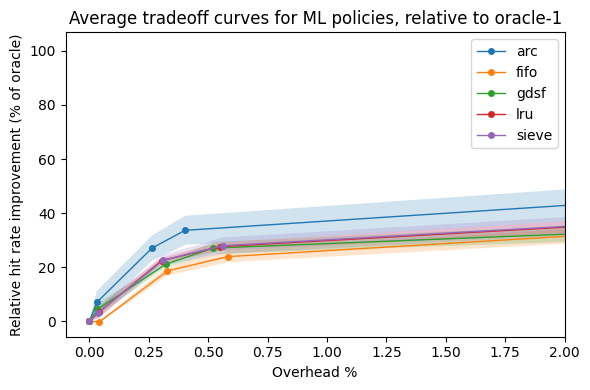

In [14]:
traces = ['fb_a', 'fb_b', 'fb_c']
rows = []
for trace in traces:
    mldf = df[(df['in'] == trace) & ((df['mode'] == 'ml') | (df['mode'] == 'never'))][['in', 'mlthres', 'optmiss', 'amp_avg', 'cache_type']]
    for ct in df['cache_type'].unique():
        nevermax = df[(df['mode'] == 'never') & (df['cache_type'] == ct) & (df['in'] == trace)]['optmiss'].values[0]
        oraclemin = df[(df['mode'] == 'oracle') & (df['cache_type'] == ct) & (df['in'] == trace) & (df['mlthres'] == 1)]['optmiss'].values[0]
        subset = mldf[mldf['cache_type'] == ct].sort_values(by='amp_avg')
        pc_oracle = (nevermax - subset['optmiss']) / (nevermax - oraclemin) * 100
        rows.append(pd.DataFrame({
            'cache_type': ct,
            'mlthres': subset['mlthres'].values,
            'amp_avg': subset['amp_avg'].values,
            'pc_oracle': pc_oracle.values
        }))

alldf = pd.concat(rows, ignore_index=True)
agg = alldf.groupby(['cache_type', 'mlthres']).agg(
    pc_oracle_mean=('pc_oracle', 'mean'),
    pc_oracle_std=('pc_oracle', 'std'),
    amp_avg_mean=('amp_avg', 'mean')
).reset_index()

plt.figure(figsize=(6, 4))
for ct in sorted(agg['cache_type'].unique()):
    sub = agg[agg['cache_type'] == ct].sort_values('mlthres')
    x = (sub['amp_avg_mean'] - 1) * 100
    y = sub['pc_oracle_mean']
    yerr = sub['pc_oracle_std'].fillna(0)
    plt.plot(x, y, marker='o', ms=4, linewidth=1, label=ct)
    plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)

plt.legend()
plt.title('Average tradeoff curves for ML policies, relative to oracle-1')
plt.xlim(-0.1, 2)
plt.xlabel('Overhead %')
plt.ylabel('Relative hit rate improvement (% of oracle)')
plt.tight_layout()
# plt.savefig('../paper/figs/ml_tradeoff_by_eviction_avg.png')
plt.show()

# results - vary zone amplification

In [75]:
files = [
    '../results/r10i1_baseline.csv',
    '../results/r10i1_ml_cf_rfc_varyza.csv',
    '../results/r10i1_ml_cf_rfc.csv',
    ]
df = pd.concat([pd.read_csv(f) for f in files])
df = df[df['cache_type'] == 'lru']
df['trace'] = df['in'].map(rename_tbl).fillna(df['in'])
df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['rv_pending'] = df.revals - df.hit_reval - df.reval_wasted
df['optmiss'] = (df['miss_all'] - df['miss_mandatory']) / df['all'] * 100
df['amp_lower'] = df['reval_wasted'] / (df['miss_all'] + df['hit_reval']) + 1
df['amp_upper'] = (df['reval_wasted'] + df['rv_pending']) / (df['miss_all'] + df['hit_reval']) + 1
df['amp_avg'] = (df['amp_lower'] + df['amp_upper']) / 2
df

,in,gib,ksr,cache_type,mode,model,mlthres,rv_min_ttl,rv_min_freq,rv_max_za,...,fetches,revals,reval_wasted,trace,miss_all,rv_pending,optmiss,amp_lower,amp_upper,amp_avg
3,cf_a,2048,1,lru,never,NaN,1.00,0,0,0.0,...,35490804,0,0,BOS 1,35490804,0,3.917737,1.000000,1.000000,1.000000
6,cf_c,2048,1,lru,never,NaN,1.00,0,0,0.0,...,60874551,0,0,DXB 1,60874551,0,6.077327,1.000000,1.000000,1.000000
10,cf_d,2048,1,lru,never,NaN,1.00,0,0,0.0,...,63600787,0,0,DXB 2,63600787,0,5.896885,1.000000,1.000000,1.000000
12,cf_e,2048,1,lru,never,NaN,1.00,0,0,0.0,...,26008122,0,0,SIN 1,26008122,0,4.392503,1.000000,1.000000,1.000000
20,cf_f,2048,1,lru,never,NaN,1.00,0,0,0.0,...,28121962,0,0,SIN 2,28121962,0,4.437352,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,cf_h,2048,1,lru,ml,models/v10_cf_rfc.onnx,0.75,0,0,0.0,...,23657161,2560015,498538,FRA 2,23657161,-1701,3.857514,1.019383,1.019317,1.019350
320,cf_h,2048,1,lru,ml,models/v10_cf_rfc.onnx,0.80,0,0,0.0,...,24402701,1443827,182334,FRA 2,24402701,-1863,4.263715,1.007104,1.007032,1.007068
321,cf_h,2048,1,lru,ml,models/v10_cf_rfc.onnx,0.70,0,0,0.0,...,23226365,3470167,895658,FRA 2,23226365,-1105,3.622798,1.034713,1.034670,1.034691
322,cf_h,2048,1,lru,ml,models/v10_cf_rfc.onnx,0.68,0,0,0.0,...,22914283,4148775,1218737,FRA 2,22914283,19,3.452763,1.047157,1.047158,1.047157


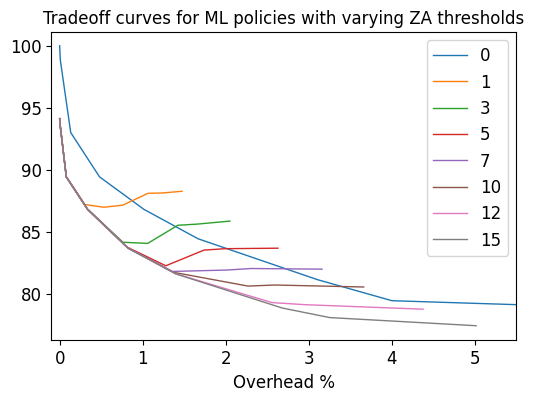

In [79]:
plt.figure(figsize=(6, 4))
for maxza in sorted(df['rv_max_za'].unique()):
    for i in sorted(df['in'].unique())[0:1]:
        subset = df[(df['rv_max_za'] == maxza) & (df['in'] == i)].sort_values(by='mlthres')
        nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
        x = (subset['amp_lower'] - 1) * 100
        y = subset['optmiss'] / nevermax * 100
        za = int(maxza * 100)
        plt.plot(x, y, marker='', ms=4, linewidth=1, label=za)
plt.xlim(-0.1, 5.5)
plt.title('Tradeoff curves for ML policies with varying ZA thresholds')
plt.xlabel('Overhead %')
plt.legend()

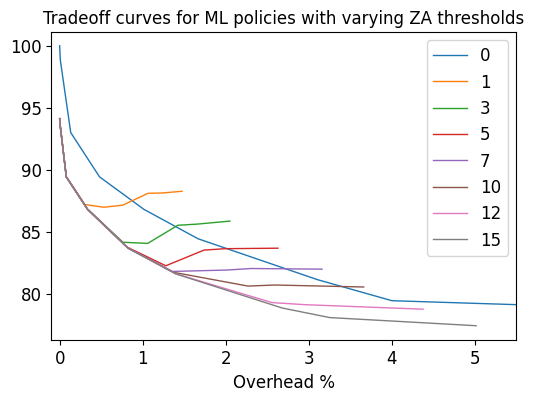

In [ ]:
plt.figure(figsize=(6, 4))
for maxza in sorted(df['rv_max_za'].unique()):
    for i in sorted(df['in'].unique())[0:1]:
        subset = df[(df['rv_max_za'] == maxza) & (df['in'] == i)].sort_values(by='mlthres')
        nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
        x = (subset['amp_lower'] - 1) * 100
        y = subset['optmiss'] / nevermax * 100
        za = int(maxza * 100)
        plt.plot(x, y, marker='', ms=4, linewidth=1, label=za)
plt.xlim(-0.1, 5.5)
plt.title('Tradeoff curves for ML policies with varying ZA thresholds')
plt.xlabel('Overhead %')
plt.legend()

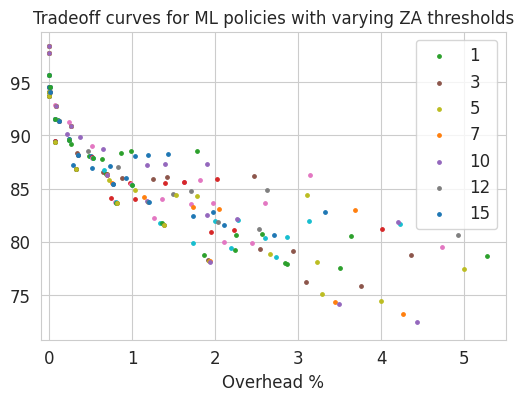

In [ ]:

plt.figure(figsize=(6, 4))
for maxza in sorted(df['rv_max_za'].unique()):
    if maxza <= 0:
        continue
    for i in sorted(df['in'].unique()):
        subset = df[(df['rv_max_za'] == maxza) & (df['in'] == i)].sort_values(by='mlthres')
        nevermax = df[(df['mode'] == 'never') & (df['in'] == i) & (df['cache_type'] == 'lru')]['optmiss'].values[0]
        # plt.plot((subset['amp_avg'] - 1) * 100, subset['optmiss'] / nevermax * 100, marker='', ms=4, linewidth=1, label=f'{rename_tbl.get(i, i)} max_za={int(maxza * 100)}')
        x = (subset['amp_avg'] - 1) * 100
        y = subset['optmiss'] / nevermax * 100
        za = int(maxza * 100)
        plt.scatter(x, y, marker='o', s=6, label=za)
        # plt.scatter((subset['amp_avg'] - 1) * 100, subset['optmiss'] / nevermax * 100, marker='', label=f'{rename_tbl.get(i, i)} max_za={int(maxza * 100)}')
plt.xlim(-0.1, 5.5)
plt.title('Tradeoff curves for ML policies with varying ZA thresholds')
plt.xlabel('Overhead %')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles)) # Dictionary keys are unique
plt.legend(by_label.values(), by_label.keys())

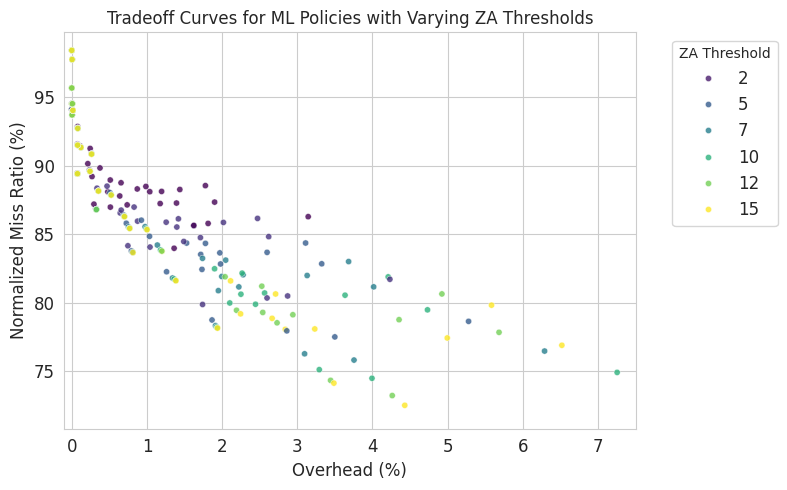

In [46]:
# 1. Prepare the Data
# Create a lookup for 'nevermax' values to make the calculation efficient
never_map = df[(df['mode'] == 'never') & (df['cache_type'] == 'lru')].set_index('in')['optmiss']

# Filter out the invalid rows and create a copy for plotting
plot_df = df[df['rv_max_za'] > 0].copy()

# Calculate the values Seaborn needs
plot_df['Overhead (%)'] = (plot_df['amp_avg'] - 1) * 100
plot_df['Normalized Miss (%)'] = plot_df.apply(
    lambda row: (row['optmiss'] / never_map.get(row['in'])) * 100, axis=1
)
plot_df['ZA'] = (plot_df['rv_max_za'] * 100).astype(int)

# 2. Create the Plot
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid") # Optional: makes the graph cleaner

# hue: groups by color and consolidates the legend
# style: (optional) gives different ZA groups different markers
sns.scatterplot(
    data=plot_df, 
    x='Overhead (%)', 
    y='Normalized Miss (%)', 
    hue='ZA', 
    palette='viridis', # A nice color gradient
    s=20,              # Marker size
    alpha=0.8          # Transparency to see overlapping points
)

# 3. Fine-tune with Matplotlib
plt.title('Tradeoff Curves for ML Policies with Varying ZA Thresholds')
plt.xlim(-0.1, 7.5)
plt.ylabel('Normalized Miss Ratio (%)')
plt.legend(title='ZA Threshold', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [39]:
# we want a scatterplot of max za v performance penalty
# for every varyza run, calculate performance penalty compared to the standard ml run
# then just plot as a scatter

varyza_df = df[(df['mode'] == 'ml') & (df['rv_max_za'] > 0)]
varyza_df['rv_max_za'].unique()

array([0.16, 0.13, 0.1 , 0.08, 0.06, 0.04, 0.02])